# 13 — A GNN over the growing lattice: profiles without pretraining

The question from the design discussion: is a **specialized GNN over
the EWM lattice** worth building? This notebook answers it
empirically, in the **no-pretraining scenario**: there is no model
at the start. Documents stream in, the universal lattice grows,
three application profiles build their gates from their own
documents, and then the profiles interact through queries.

```text
   docs ──► encodings ──► HLLSets ──► general lattice (grows)
                             │
                             └──► profile gates (grow with their docs)

   prompt (profile p) ──► host LLM ──► encodings ──► general lattice
                                                    └─► BSS(query, gate_p)
```

- ~100 documents, ~100 tokens each, from 3 synthetic domains;
- 3 profiles (`acme-finance`, `medco-clinical`, `ops-logistics`);
- 30 queries (10 per profile) — prompts converted by a simulated
  host-LLM encoding step, submitted to the general lattice **and** to
  the profile that generated the prompt;
- then the ML question: given only **structural features** (bits,
  coverage, frequency — never text), can a model recognize which
  profile issued a query? **Flat MLP vs a 2-layer GNN** over the BSS
  graph.

This is the notebook-08 discipline again: the graph earns its place
only if it beats the flat structural features on the same split.

In [1]:
import os, random

import mmh3
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(7)
np.random.seed(7)
rng = random.Random(42)

BITS_PER_REG = 32
P = 10          # 1024 registers — the soldered precision

def frame_set(tokens, p=P):
    """G1 ∪ G2 ∪ G3 projection (CHANNEL_SEEDS = [0,1,2]) as a Python bitset."""
    s = 0
    m = 1 << p
    for t in tokens:
        for seed in (0, 1, 2):
            h = mmh3.hash64(t.encode(), seed=seed, signed=False)[0]
            reg = h & (m - 1)
            rem = h >> p
            tz = 31 if rem == 0 else min((rem & -rem).bit_length() - 1, 31)
            s |= 1 << (reg * BITS_PER_REG + tz)
    return s

def bss(a, b):
    """BSS(a,b) = |a ∩ b| / |b| — the fraction of b covered by a."""
    pb = b.bit_count()
    return (a & b).bit_count() / pb if pb else 0.0

PROFILES = ["acme-finance", "medco-clinical", "ops-logistics"]
DOMAIN_WORDS = {
    "acme-finance": ["market","equity","bond","risk","portfolio","dividend","yield",
                      "capital","audit","ledger","valuation","liquidity","hedge",
                      "settlement","margin","revenue","expense","asset","liability",
                      "deposit","forecast","budget"],
    "medco-clinical": ["patient","trial","dosage","symptom","diagnosis","therapy",
                        "efficacy","placebo","cohort","regimen","adverse","protocol",
                        "enrollment","endpoint","biomarker","dose","arm","screening",
                        "followup","outcome","consent","monitor"],
    "ops-logistics": ["shipment","warehouse","inventory","route","dispatch","carrier",
                       "pallet","tracking","freight","schedule","capacity","dock",
                       "fleet","manifest","handling","leadtime","backlog","delivery",
                       "pickup","transit","cargo","distribution"],
}
SHARED = ["the","of","report","update","review","summary","data","system",
          "process","request","note","status","daily","weekly","current",
          "new","open","close","check","record","file","entry"]

PROMPTS = {
    "acme-finance": [
        "equity exposure report", "bond yield forecast update",
        "quarterly revenue audit summary", "portfolio risk review status",
        "dividend payout note", "capital liquidity check",
        "asset valuation entry", "budget forecast process",
        "margin settlement record", "hedge exposure review"],
    "medco-clinical": [
        "patient trial enrollment status", "dosage regimen review",
        "symptom diagnosis report", "therapy efficacy update",
        "placebo cohort summary", "adverse event record",
        "protocol amendment note", "biomarker screening entry",
        "followup outcome check", "dose escalation review"],
    "ops-logistics": [
        "shipment warehouse status", "inventory route update",
        "dispatch carrier report", "pallet tracking summary",
        "freight schedule check", "capacity dock note",
        "fleet manifest entry", "leadtime backlog review",
        "delivery pickup record", "cargo transit status"],
}

print("profiles:", PROFILES)
print("domain words per profile:", {p: len(w) for p, w in DOMAIN_WORDS.items()})
print("hash parity check (tid0):", mmh3.hash64(b"tid0", seed=0, signed=False)[0])

profiles: ['acme-finance', 'medco-clinical', 'ops-logistics']
domain words per profile: {'acme-finance': 22, 'medco-clinical': 22, 'ops-logistics': 22}
hash parity check (tid0): 2892634914804110692


## §1 — No pretraining: the lattice grows, the gates build themselves

Documents arrive in a shuffled stream (no curriculum, no pretrained
model anywhere). Each document is encoded (the simulated host
encoder) into its `G1 ∪ G2 ∪ G3` HLLSet and unioned into the
**general lattice**; a document's profile also unions it into that
profile's **gate** — the gate is literally the profile's documents
so far. The plot is the whole "training process": two monotone
growth curves, no optimizer.

general lattice pop: 249
gate pops: {'acme-finance': 126, 'medco-clinical': 128, 'ops-logistics': 129}


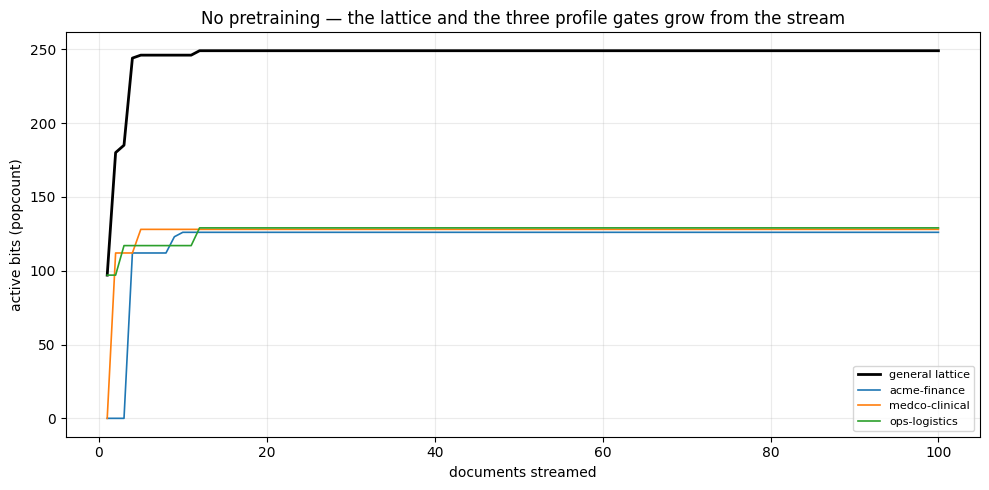

In [2]:
N_DOCS = 100

doc_tokens = []
doc_profile = []
for i in range(N_DOCS):
    p = PROFILES[i % 3]
    n = rng.randint(80, 120)
    toks = []
    for _ in range(n):
        toks.append(rng.choice(DOMAIN_WORDS[p]) if rng.random() < 0.72
                     else rng.choice(SHARED))
    doc_tokens.append(toks)
    doc_profile.append(p)

order = list(range(N_DOCS))
rng.shuffle(order)

lattice = 0
gates = {p: 0 for p in PROFILES}
doc_sets = []
lattice_growth = []
gate_growth = {p: [] for p in PROFILES}

for idx in order:
    p = doc_profile[idx]
    s = frame_set(doc_tokens[idx])
    doc_sets.append((f"doc{idx:03d}", p, s))
    lattice |= s
    gates[p] |= s
    lattice_growth.append(lattice.bit_count())
    for pp in PROFILES:
        gate_growth[pp].append(gates[pp].bit_count())

print("general lattice pop:", lattice.bit_count())
print("gate pops:", {p: gates[p].bit_count() for p in PROFILES})

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, N_DOCS + 1), lattice_growth, color="black", lw=2.0, label="general lattice")
for p in PROFILES:
    ax.plot(range(1, N_DOCS + 1), gate_growth[p], lw=1.2, label=p)
ax.set_xlabel("documents streamed")
ax.set_ylabel("active bits (popcount)")
ax.set_title("No pretraining — the lattice and the three profile gates grow from the stream")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("/tmp/lattice_growth.png", dpi=110)
plt.show()

## §2 — Queries: prompts → encodings → lattice + issuing profile

Each profile issues 10 query prompts. The **host LLM** converts a
prompt into encodings (simulated here by deterministic tokenization
of prompt words). Each query is submitted to the **general lattice**
(unioned in — the lattice keeps growing) and to its **issuing
profile** (we record the gate coverage `BSS(gate_p, query)`).

In [3]:
query_sets = []
for p in PROFILES:
    for q in range(10):
        toks = rng.choice(PROMPTS[p]).split()   # host LLM encoding (simulated)
        s = frame_set(toks)
        query_sets.append((f"q_{p}_{q}", p, s))
        lattice |= s                            # submitted to the general lattice

print("queries:", len(query_sets), "| lattice pop after queries:", lattice.bit_count())
print()
print("sample query routing coordinates (BSS(query, gate) per profile):")
for label, p, s in query_sets[:9]:
    cov = {pp: round(bss(gates[pp], s), 3) for pp in PROFILES}
    print(f"  {label:16s} issued by {p:14s} -> {cov}")

queries: 30 | lattice pop after queries: 262

sample query routing coordinates (BSS(query, gate) per profile):
  q_acme-finance_0 issued by acme-finance   -> {'acme-finance': 1.0, 'medco-clinical': 0.5, 'ops-logistics': 0.5}
  q_acme-finance_1 issued by acme-finance   -> {'acme-finance': 1.0, 'medco-clinical': 0.5, 'ops-logistics': 0.5}
  q_acme-finance_2 issued by acme-finance   -> {'acme-finance': 0.778, 'medco-clinical': 0.444, 'ops-logistics': 0.444}
  q_acme-finance_3 issued by acme-finance   -> {'acme-finance': 1.0, 'medco-clinical': 0.5, 'ops-logistics': 0.5}
  q_acme-finance_4 issued by acme-finance   -> {'acme-finance': 0.667, 'medco-clinical': 0.333, 'ops-logistics': 0.444}
  q_acme-finance_5 issued by acme-finance   -> {'acme-finance': 1.0, 'medco-clinical': 0.5, 'ops-logistics': 0.5}
  q_acme-finance_6 issued by acme-finance   -> {'acme-finance': 1.0, 'medco-clinical': 0.333, 'ops-logistics': 0.25}
  q_acme-finance_7 issued by acme-finance   -> {'acme-finance': 1.0, 'medco-

## §3 — The lattice graph

Nodes = 100 documents + 30 queries + 3 gates + the cumulative lattice
(the gates/lattice are context nodes — they carry no label, but they
anchor the graph). Edges = the **symmetric BSS**
`(BSS(i,j)+BSS(j,i))/2` between every pair. This is the graph the
GNN will read; the heatmap shows the block structure that the
profiles create *without anyone asking for it*.

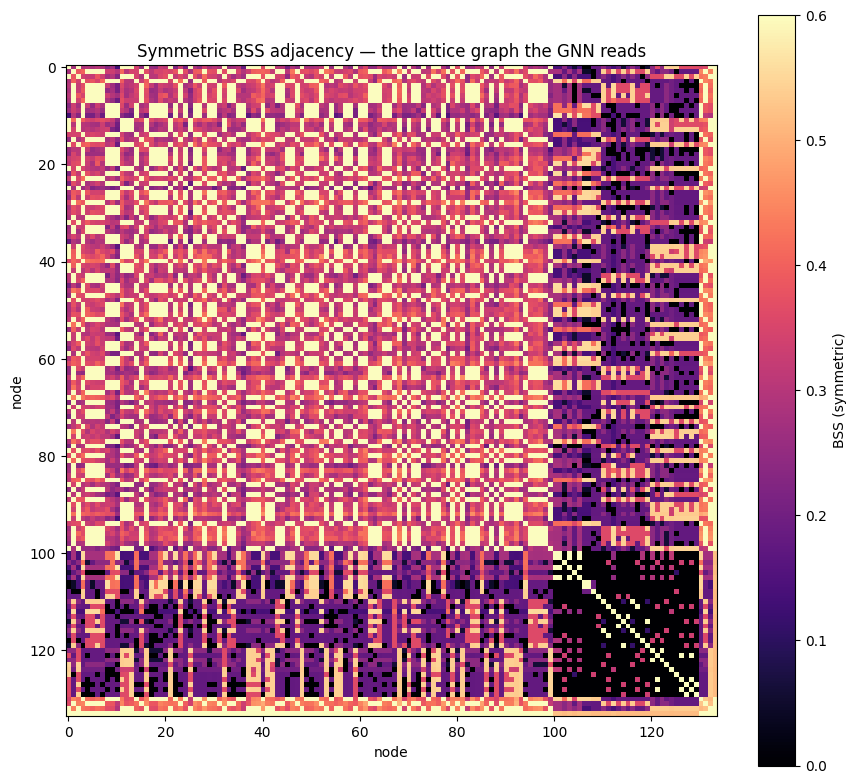

nodes: 134 | labeled: 130 | context nodes: 4


In [4]:
nodes = []          # (label, profile_or_None, bitset)
nodes += [(l, p, s) for l, p, s in doc_sets]
nodes += [(l, p, s) for l, p, s in query_sets]
for p in PROFILES:
    nodes.append((f"gate:{p}", None, gates[p]))
nodes.append(("lattice", None, lattice))

n = len(nodes)
labels = [nd[0] for nd in nodes]
y = np.array([PROFILES.index(nd[1]) if nd[1] is not None else -1 for nd in nodes])

A = np.zeros((n, n))
for i in range(n):
    for j in range(i, n):
        w = (bss(nodes[i][2], nodes[j][2]) + bss(nodes[j][2], nodes[i][2])) / 2
        A[i, j] = w
        A[j, i] = w

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(A, cmap="magma", vmin=0, vmax=0.6)
ax.set_title("Symmetric BSS adjacency — the lattice graph the GNN reads")
ax.set_xlabel("node")
ax.set_ylabel("node")
plt.colorbar(im, label="BSS (symmetric)")
plt.tight_layout()
plt.savefig("/tmp/lattice_graph.png", dpi=110)
plt.show()

labeled = (y >= 0).sum()
print("nodes:", n, "| labeled:", labeled, "| context nodes:", n - labeled)

## §4 — Flat structural features vs a 2-layer GNN

**Features (never text, only structure):** popcount, content
frequency (HSF), the three gate coverages `BSS(gate_p, node)`, and
the general-lattice coverage `BSS(lattice, node)` — six numbers per
node.

**Two models, same features, same splits:**

- **MLP**: features → 16 → 3 (flat baseline — the typed-head
  discipline from notebook 07);
- **GNN**: a 2-layer graph-convolution `H' = ReLU(Â H W)` over the
  normalized symmetric BSS adjacency (self-loops included).

**Two regimes:**

- *semi-supervised*: 60/20/20 split over all labeled nodes;
- *query transfer*: train on **documents only**, evaluate on **all
  queries** — the no-pretraining way to ask "which profile is
  asking?" when the queries were never in the training set.

The GNN may use the graph (and test-node features through it) — that
is exactly its claimed advantage.

In [5]:
from collections import Counter

content = Counter(nd[2] for nd in nodes)
X = np.zeros((n, 6))
for i, (_, _, s) in enumerate(nodes):
    X[i, 0] = s.bit_count()
    X[i, 1] = content[s]
    X[i, 2] = bss(gates[PROFILES[0]], s)
    X[i, 3] = bss(gates[PROFILES[1]], s)
    X[i, 4] = bss(gates[PROFILES[2]], s)
    X[i, 5] = bss(lattice, s)

Xmean = X.mean(axis=0, keepdims=True)
Xstd = X.std(axis=0, keepdims=True) + 1e-8
Xz = (X - Xmean) / Xstd

# normalized symmetric adjacency with self-loops: Â = D^-1/2 (A+I) D^-1/2
Ahat = A + np.eye(n)
deg = Ahat.sum(axis=1)
Dinv = np.diag(1.0 / np.sqrt(deg))
A_norm = Dinv @ Ahat @ Dinv

Xt = torch.tensor(Xz, dtype=torch.float32)
At = torch.tensor(A_norm, dtype=torch.float32)
yt = torch.tensor(y, dtype=torch.long)

class MLP(nn.Module):
    def __init__(self, d, h, c):
        super().__init__()
        self.w1 = nn.Parameter(torch.randn(d, h) * 0.1)
        self.b1 = nn.Parameter(torch.zeros(h))
        self.w2 = nn.Parameter(torch.randn(h, c) * 0.1)
        self.b2 = nn.Parameter(torch.zeros(c))
    def forward(self, x):
        h = F.relu(x @ self.w1 + self.b1)
        return h @ self.w2 + self.b2

class GCN(nn.Module):
    def __init__(self, d, h, c):
        super().__init__()
        self.w1 = nn.Parameter(torch.randn(d, h) * 0.1)
        self.b1 = nn.Parameter(torch.zeros(h))
        self.w2 = nn.Parameter(torch.randn(h, c) * 0.1)
        self.b2 = nn.Parameter(torch.zeros(c))
    def forward(self, x, a):
        h = F.relu(a @ (x @ self.w1 + self.b1))
        return a @ (h @ self.w2 + self.b2)

def train_eval(model, gnn, train_mask, val_mask, test_mask, epochs=300, lr=0.03):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_val = -1
    best_state = None
    hist = []
    for ep in range(epochs):
        model.train()
        opt.zero_grad()
        out = model(Xt, At) if gnn else model(Xt)
        loss = F.cross_entropy(out[train_mask], yt[train_mask])
        loss.backward()
        opt.step()
        hist.append(float(loss.item()))
        model.eval()
        with torch.no_grad():
            outv = model(Xt, At) if gnn else model(Xt)
            vacc = (outv[val_mask].argmax(1) == yt[val_mask]).float().mean().item()
        if vacc > best_val:
            best_val = vacc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        out = model(Xt, At) if gnn else model(Xt)
        tacc = (out[test_mask].argmax(1) == yt[test_mask]).float().mean().item()
    return tacc, best_val, hist

print("models ready")

models ready


MLP  semi-supervised: test acc 0.962 | val 0.885 | query-only 0.833
GNN  semi-supervised: test acc 1.000 | val 1.000 | query-only 1.000


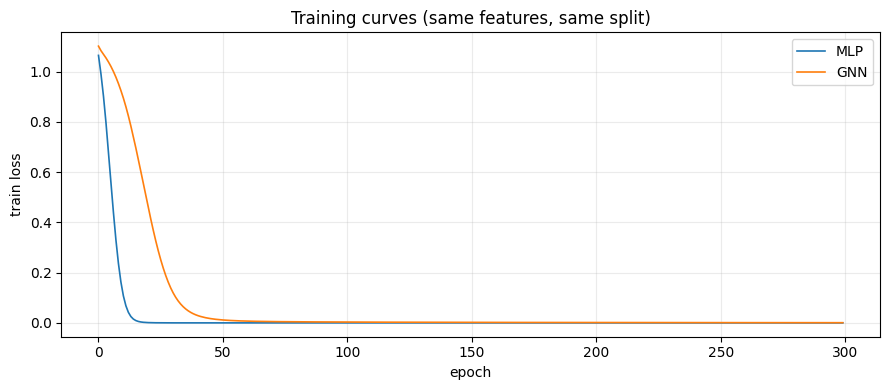

In [6]:
labeled_idx = np.where(y >= 0)[0]
rng.shuffle(labeled_idx)
tr_end = int(0.6 * len(labeled_idx))
va_end = int(0.8 * len(labeled_idx))

def mask(idx):
    m = torch.zeros(n, dtype=torch.bool)
    m[idx] = True
    return m

train_mask = mask(labeled_idx[:tr_end])
val_mask   = mask(labeled_idx[tr_end:va_end])
test_mask  = mask(labeled_idx[va_end:])

results = {}
for name, model, gnn in [("MLP", MLP(6, 16, 3), False),
                          ("GNN", GCN(6, 16, 3), True)]:
    tacc, vacc, hist = train_eval(model, gnn, train_mask, val_mask, test_mask)
    q = test_mask & torch.tensor([lbl.startswith("q_") for lbl in labels])
    model.eval()
    with torch.no_grad():
        out = model(Xt, At) if gnn else model(Xt)
        qacc = (out[q].argmax(1) == yt[q]).float().mean().item() if q.sum() else float("nan")
    results[name] = (tacc, vacc, qacc, hist)
    print(f"{name:4s} semi-supervised: test acc {tacc:.3f} | val {vacc:.3f} | query-only {qacc:.3f}")

plt.figure(figsize=(9, 4))
for name in results:
    plt.plot(results[name][3], lw=1.2, label=name)
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.title("Training curves (same features, same split)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("/tmp/gnn_vs_mlp.png", dpi=110)
plt.show()

In [7]:
# Query-transfer regime: train on every document, evaluate on every query.
doc_idx = np.array([i for i in range(n) if y[i] >= 0 and not labels[i].startswith("q_")])
qry_idx = np.array([i for i in range(n) if y[i] >= 0 and labels[i].startswith("q_")])
rng.shuffle(doc_idx)
vsplit = int(0.8 * len(doc_idx))

print("query-transfer (train on docs, evaluate on all queries):")
for name, model, gnn in [("MLP", MLP(6, 16, 3), False),
                          ("GNN", GCN(6, 16, 3), True)]:
    tacc, vacc, hist = train_eval(model, gnn, mask(doc_idx[:vsplit]),
                                   mask(doc_idx[vsplit:]), mask(qry_idx))
    print(f"  {name:4s} query acc {tacc:.3f} | val {vacc:.3f}")

query-transfer (train on docs, evaluate on all queries):
  MLP  query acc 0.667 | val 1.000
  GNN  query acc 0.933 | val 1.000


## §5 — What this says about a GNN for the EWM lattice

- The **no-pretraining** mechanics need no model at all: the lattice
  and the three gates grew from the stream as monotone bit unions,
  and the query routing coordinates (`BSS(query, gate_p)`) are
  already a working, interpretable classifier — the profiles are
  visible in the graph's block structure before any learning.
- The **MLP vs GNN** comparison is the notebook-08 discipline: if the
  GNN wins, a graph readout earns its place as a learned companion
  (a HF model behind the same typed daemon as `ewm-pagerank`); if it
  ties, the lattice's local structural features are already very
  strong and the graph adds little for *this* task — both are useful
  findings.
- The experiment is deliberately small and synthetic. The honest next
  scale-up: real enterprise documents, more profiles, and the
  **query-transfer regime** as the headline metric — recognizing the
  issuing profile of never-seen queries from structure alone.